# Lab 11: 3D Genome Structure - Introduction (pt.2)

Data source: https://www.ncbi.nlm.nih.gov/geo/query/acc.cgi?acc=GSM935611

- **Exercise 1**: TAD calling (contd. from prev. week)
- **Exercise 2**: ChIP-seq downstream analysis

In [10]:
#!uv add pyranges
#!uv add pyBigWig  # standard, but MIGHT NOT WORK ON WINDOWS:( -> use bedGraph file instead

# import pyBigWig
import pyranges as pr
import cooler
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [11]:
def plot_hic_matrix(mat, title="Hi-C Contact Map", cmap='Reds', max_color=None, show=True):
    """Plot heatmap of Hi-C matrix"""
    plt.figure(figsize=(8, 8))
    if isinstance(max_color, float):
        max_color = np.percentile(mat, max_color)    
    plt.imshow(mat, origin='upper', cmap=cmap, vmax=max_color)
    plt.colorbar(label="Contact strength")
    plt.title(title)
    plt.xlabel("Bin")
    plt.ylabel("Bin")
    plt.tight_layout()
    if show:        
        plt.show()

def fetch_region_cooler(mcool_path, chrom, start, end, resolution):
    if chrom.startswith('chr'):
        chrom = chrom[3:]  # remove 'chr' prefix for cooler
    c = cooler.Cooler(f"{mcool_path}::resolutions/{resolution}")
    return c.matrix(balance=False).fetch(f"{chrom}:{start}-{end}")

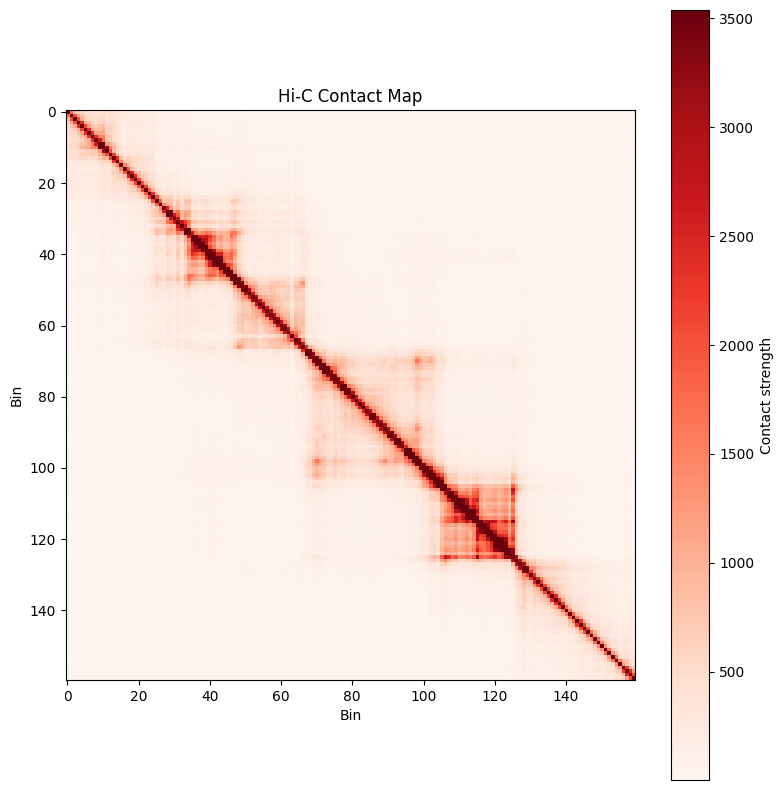

In [12]:
_mcool_file = '../notebooks-solutions/lab_outputs/rao/GSE63525_GM12878_insitu_primary+replicate_combined.mcool'

sample_region_small = ('chr2', 134_000_000, 138_000_000)
sample_region_small_hic = fetch_region_cooler(_mcool_file, *sample_region_small, 25_000)
plot_hic_matrix(sample_region_small_hic, title="Hi-C Contact Map", max_color=99.0)

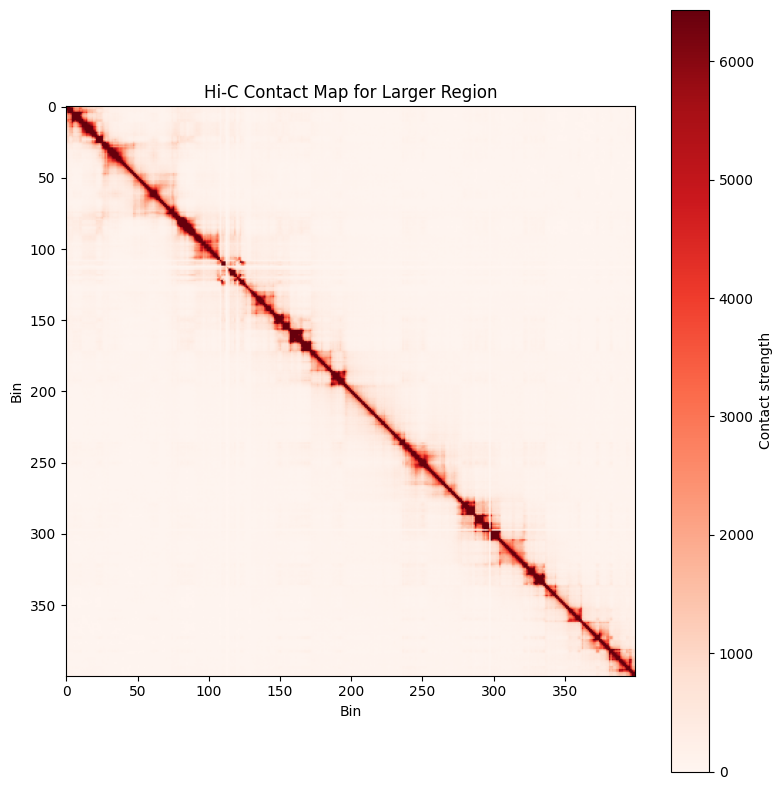

In [13]:
sample_region_big = ('chr2', 120_000_000, 160_000_000)
sample_compartment_resolution = 100_000
sample_region_big_hic_mat = fetch_region_cooler(_mcool_file, *sample_region_big, sample_compartment_resolution)

plot_hic_matrix(sample_region_big_hic_mat, title="Hi-C Contact Map for Larger Region", max_color=99.0)

---
## Exercise 1: TAD calling (contd.)

**Goals:**
1. Detect TAD boundaries using insulation score

In [14]:
def compute_insulation_score(mat, window=5):
    """Compute insulation score for TAD boundary detection."""
    n = mat.shape[0]
    insulation = np.zeros(n)
    for i in range(n):
        start = max(0, i-window)
        end = min(n, i+window+1)
        submat = mat[start:end, start:end]
        insulation[i] = submat.sum()
    return insulation


def detect_tad_boundaries(insulation, smooth=3):
    """Detect TAD boundaries as local minima in insulation score."""
    n = len(insulation)
    print(n)
    if smooth:
        ins_cs = np.cumsum(insulation)
        ins_cs[smooth:] = ins_cs[smooth:] - ins_cs[:-smooth]
        insulation[smooth//2:-smooth//2+1] = ins_cs[smooth - 1:] / smooth
    boundaries = [
        i for i in range(1, n-1)
        if insulation[i] < insulation[i-1] and insulation[i] < insulation[i+1]
    ]
    return boundaries


def get_tad_regions(boundaries, n_bins):
    """Convert TAD boundaries to a list of TAD regions (start, end)."""
    regions = []
    start = 0
    for b in boundaries:
        regions.append((start, b))
        start = b
    regions.append((start, n_bins))
    return regions

160
Found 9 TAD boundaries
Extracted 9 TADs


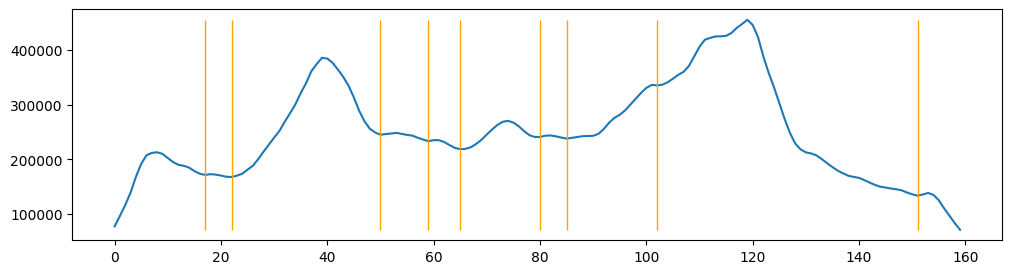

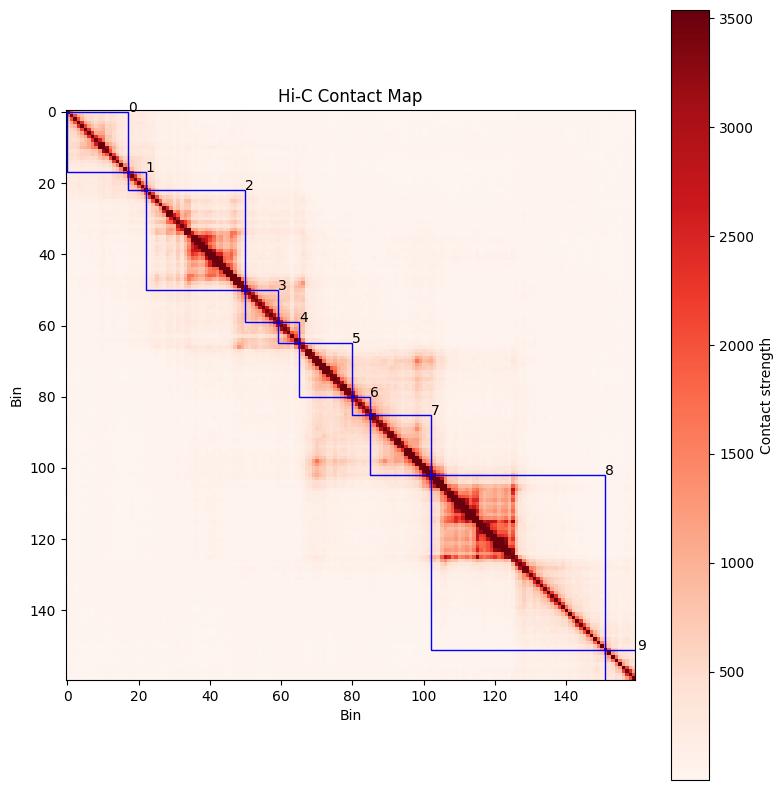

In [15]:
from matplotlib.patches import Rectangle

insulation_score = compute_insulation_score(sample_region_small_hic, window=5)
tad_boundaries = detect_tad_boundaries(insulation_score, smooth=3)
print(f"Found {len(tad_boundaries)} TAD boundaries")
tad_regions = get_tad_regions(tad_boundaries, insulation_score.shape[0])
print(f"Extracted {len(tad_boundaries)} TADs")

plt.figure(figsize=(12, 3))
plt.plot(insulation_score);
plt.vlines(tad_boundaries, ymin=insulation_score.min(), ymax=insulation_score.max(), color='orange', linewidth=1);

plot_hic_matrix(sample_region_small_hic, title="Hi-C Contact Map", max_color=99.0, show=False)
ax = plt.gca()
for i, (tad_start, tad_end) in enumerate(tad_regions):
    tad_size = tad_end - tad_start
    ax.add_patch(
        Rectangle((tad_start, tad_start), tad_size, tad_size,
                  edgecolor='blue', linewidth=1, fill=False)
    )
    ax.text(tad_start + tad_size, tad_start, str(i))

**TODO**:

Play with windows size and smoothing to get a different result. What else can be done with the raw signal?

---
## Exercise 2: ChIP-seq downstream analysis

**Goals:**
1. Load and visuzlize ChIP-seq signal and peaks.
2. Intersect the peaks with the motifs - use `pyranges`

_Note: The "peak calling" step is outside the scope of this class_

In [16]:
chipseq_signal = pr.read_bed("../notebooks-solutions/lab_outputs/GSM935611_chr2.bedGraph.gz")  # works fine despite name
chipseq_signal.columns = ['Chromosome', "Start", "End", "Score"]  # for some reason the Score columns is present as "Name"
chipseq_signal

,Chromosome,Start,End,Score
0,chr2,10086,10286,1
1,chr2,10321,10365,1
2,chr2,10365,10521,2
3,chr2,10521,10565,1
4,chr2,11262,11347,1
...,...,...,...,...
3524109,chr2,243181165,243181333,1
3524110,chr2,243181396,243181459,1
3524111,chr2,243181459,243181596,2
3524112,chr2,243181596,243181659,1


In [17]:
chipseq_peaks = pr.read_bed("../notebooks-solutions/lab_outputs/GSM935611_hg19_wgEncodeSydhTfbsGm12878Ctcfsc15914c20StdPk.narrowPeak.gz")
chipseq_peaks

,Chromosome,Start,End,Name,Score,Strand,ThickStart,ThickEnd,ItemRGB,BlockCount
0,chr1,47902049,47903879,.,1000,.,128.20841,300.00000,300.00000,251
1,chr1,110074831,110075866,.,1000,.,115.91322,300.00000,300.00000,270
2,chr1,113615136,113616445,.,1000,.,123.19150,300.00000,300.00000,495
3,chr1,146713976,146715283,.,1000,.,100.08747,300.00000,300.00000,261
4,chr1,178511224,178512574,.,1000,.,124.64416,300.00000,300.00000,567
...,...,...,...,...,...,...,...,...,...,...
79952,chrX,103767114,103767299,.,370,.,3.45380,2.07312,2.02171,155
79953,chrX,109083292,109083415,.,370,.,3.45380,2.07312,2.02172,54
79954,chrX,131910938,131911116,.,370,.,3.45380,2.07312,2.02172,82
79955,chrX,16825696,16825979,.,370,.,2.13323,2.05716,2.00658,154


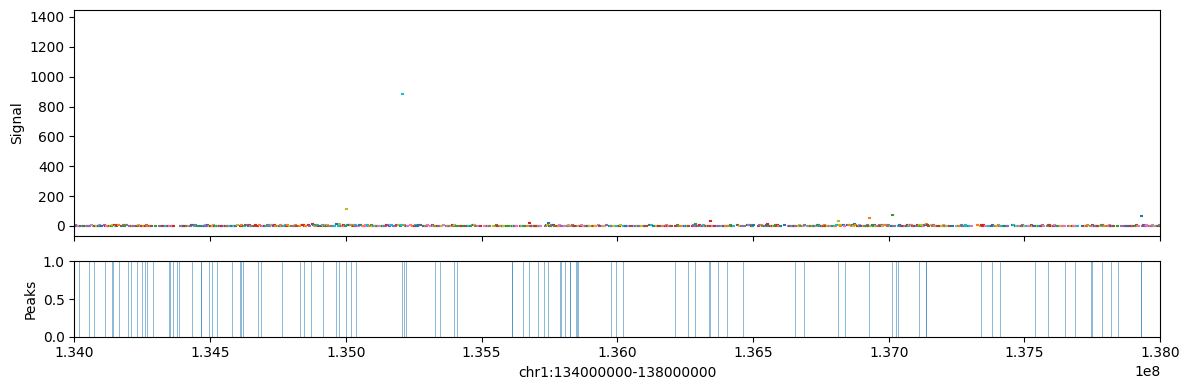

In [18]:
def plot_region(bw_region, peaks_region, chromosome, start, end):
    bw_region = chipseq_signal[chipseq_signal.Chromosome == chromosome]
    bw_region = bw_region[(bw_region.Start < end) & (bw_region.End > start)]

    chipseq_peaks_region = chipseq_peaks[chipseq_peaks.Chromosome == chromosome]
    chipseq_peaks_region = chipseq_peaks_region[(chipseq_peaks_region.Start < end) & (chipseq_peaks_region.End > start)]

    fig, (ax1, ax2) = plt.subplots(
        2, 1, sharex=True, figsize=(12, 4),
        gridspec_kw={"height_ratios": [3, 1]}
    )

    # ---- Signal track ----
    for row in bw_region.df.itertuples():
        ax1.plot([row.Start, row.End], [row.Score, row.Score])

    ax1.set_ylabel("Signal")

    # ---- Peaks track ----
    for row in peaks_region.df.itertuples():
        ax2.axvspan(row.Start, row.End, alpha=0.5)

    ax2.set_xlim(start, end)
    ax2.set_ylabel("Peaks")
    ax2.set_xlabel(f"chr1:{start}-{end}")

    plt.tight_layout()
    plt.show()

plot_region(
    chipseq_signal,
    chipseq_peaks,
    *sample_region_small
)

In [21]:
d = 50_000  # example - try different values
resolution = 25_000
_df = pd.DataFrame.from_dict({
    'Chromosome': sample_region_small[0],
    'Start': tad_boundaries,
    'End': tad_boundaries,
    'TadIdx': range(1, len(tad_boundaries) + 1)
})
_df['Start'] = _df['Start'] * resolution - d + sample_region_small[1]
_df['End'] = _df['End'] * resolution + d + sample_region_small[1]
tad_boundaries_pr = pr.PyRanges(_df)
tad_boundaries_pr

,Chromosome,Start,End,TadIdx
0,chr2,134375000,134475000,1
1,chr2,134500000,134600000,2
2,chr2,135200000,135300000,3
3,chr2,135425000,135525000,4
4,chr2,135575000,135675000,5
5,chr2,135950000,136050000,6
6,chr2,136075000,136175000,7
7,chr2,136500000,136600000,8
8,chr2,137725000,137825000,9


In [22]:
joined_peaks = tad_boundaries_pr.join(chipseq_peaks)
joined_peaks

,Chromosome,Start,End,TadIdx,Start_b,End_b,Name,Score,Strand,ThickStart,ThickEnd,ItemRGB,BlockCount
0,chr2,134375000,134475000,1,134399211,134399538,.,546,.,7.78651,7.29724,7.04757,141
1,chr2,134500000,134600000,2,134537664,134538080,.,1000,.,65.25843,95.31363,94.51252,215
2,chr2,134500000,134600000,2,134592169,134592384,.,514,.,17.69877,6.36251,6.13946,88
3,chr2,135200000,135300000,3,135208322,135208879,.,1000,.,104.40974,206.79634,204.66704,290
4,chr2,135200000,135300000,3,135218062,135218506,.,1000,.,63.40449,92.37747,91.59253,214
5,chr2,135200000,135300000,3,135223698,135224111,.,1000,.,38.56179,53.31338,52.70896,207
6,chr2,135200000,135300000,3,135249492,135249674,.,451,.,15.57303,4.48121,4.31905,68
7,chr2,135200000,135300000,3,135293046,135293105,.,393,.,17.00590,2.76726,2.68270,29
8,chr2,135425000,135525000,4,135450109,135450433,.,701,.,14.08988,11.81452,11.48340,168
9,chr2,135425000,135525000,4,135461952,135461999,.,382,.,9.64044,2.43266,2.36612,12


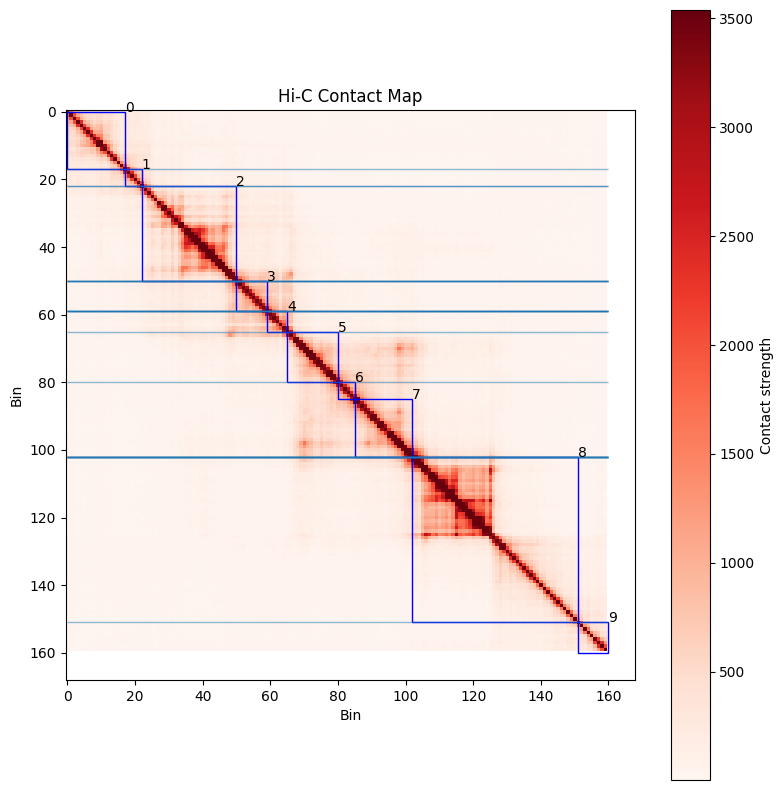

In [24]:
plot_hic_matrix(sample_region_small_hic, title="Hi-C Contact Map", max_color=99.0, show=False)
ax = plt.gca()
for i, (tad_start, tad_end) in enumerate(tad_regions):
    tad_size = tad_end - tad_start
    ax.add_patch(
        Rectangle((tad_start, tad_start), tad_size, tad_size,
                  edgecolor='blue', linewidth=1, fill=False)
    )
    ax.text(tad_start + tad_size, tad_start, str(i))

lines = []
for _, s, e, *_ in joined_peaks.df.itertuples(index=False):
# for _, s, e, *_ in chipseq_peaks.df.itertuples(index=False):
    c = (s + e) // 2
    c -= sample_region_small[1]
    c //= resolution
    if c >= 0 and c <= 160:
        lines.append(c)
ax.hlines(lines, xmin=0, xmax=sample_region_small_hic.shape[0], alpha=0.5, linewidth=1);